# Hospital Readmission Classification

**Goal:** Predict 30-day hospital readmission (`readmitted < 30`) for diabetic inpatient encounters using the Diabetes 130-US Hospitals dataset (~102k encounters).

**Approach:** EDA → preprocessing (missingness, discharge filters, rare-category collapse) → **patient-level** train/test split → compare **Logistic Regression** (balanced), **Random Forest** (tuned), and **XGBoost** (tuned, `scale_pos_weight`) under class imbalance (~11% positive) → tune the decision threshold by F1.

**Highlight:** XGBoost ranks best (ROC-AUC ~0.65, PR-AUC ~0.22). A **0.55** threshold (max F1) is the chosen operating point. Accuracy alone is misleading — RF looks strong (~87%) but recovers very few early readmissions (recall ~0.09).

**Write-up:** [`projects/hospital-readmission/`](../projects/hospital-readmission/)


## 1. Imports


In [94]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    recall_score,
    classification_report,
    roc_curve,
    precision_recall_curve
)
from sklearn.metrics import precision_score, f1_score
from sklearn.ensemble import RandomForestClassifier


## 2. Load Data


In [95]:
from pathlib import Path

# Project-relative path (works whether cwd is repo root or notebooks/)
ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent

DATA_PATH = ROOT / "data" / "raw" / "hospital-readmission" / "diabetic_data.csv"
data = pd.read_csv(DATA_PATH)
data.head()

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


## 3. Data Overview


In [96]:
# Variable information
data.info()

#shape
data.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 50 columns):
 #   Column                    Non-Null Count   Dtype 
---  ------                    --------------   ----- 
 0   encounter_id              101766 non-null  int64 
 1   patient_nbr               101766 non-null  int64 
 2   race                      101766 non-null  object
 3   gender                    101766 non-null  object
 4   age                       101766 non-null  object
 5   weight                    101766 non-null  object
 6   admission_type_id         101766 non-null  int64 
 7   discharge_disposition_id  101766 non-null  int64 
 8   admission_source_id       101766 non-null  int64 
 9   time_in_hospital          101766 non-null  int64 
 10  payer_code                101766 non-null  object
 11  medical_specialty         101766 non-null  object
 12  num_lab_procedures        101766 non-null  int64 
 13  num_procedures            101766 non-null  int64 
 14  num_

(101766, 50)

The response variable is **readmitted**, which is categorical. There are **101,766 encounters** and **50 columns** (including the target). Note that rows are encounters, not unique patients — the same patient can appear more than once via `patient_nbr`.


In [97]:
num_cols = data.select_dtypes(include=['int64','float64']).columns
cat_cols = data.select_dtypes(include='object').columns

print("Numerical columns:", len(num_cols))
print(list(num_cols))
print("\nCategorical columns:", len(cat_cols))
print(list(cat_cols))

Numerical columns: 13
['encounter_id', 'patient_nbr', 'admission_type_id', 'discharge_disposition_id', 'admission_source_id', 'time_in_hospital', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'number_diagnoses']

Categorical columns: 37
['race', 'gender', 'age', 'weight', 'payer_code', 'medical_specialty', 'diag_1', 'diag_2', 'diag_3', 'max_glu_serum', 'A1Cresult', 'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide', 'examide', 'citoglipton', 'insulin', 'glyburide-metformin', 'glipizide-metformin', 'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone', 'change', 'diabetesMed', 'readmitted']


There are **13 numerical variables** and **37 categorical/object variables** among the columns (exact dtype split depends on how IDs are stored). Identifier fields such as `encounter_id` and `patient_nbr` are not useful as model features.


### Missingness


In [98]:
missing = (
    data.replace("?", pd.NA)
    .isna()
    .mean()
    .mul(100)
    .sort_values(ascending=False)
)
missing[missing > 0]


weight               96.858479
max_glu_serum        94.746772
A1Cresult            83.277322
medical_specialty    49.082208
payer_code           39.557416
race                  2.233555
diag_3                1.398306
diag_2                0.351787
diag_1                0.020636
dtype: float64

### Duplicates


In [99]:
data.duplicated().sum()

0

### Target distribution


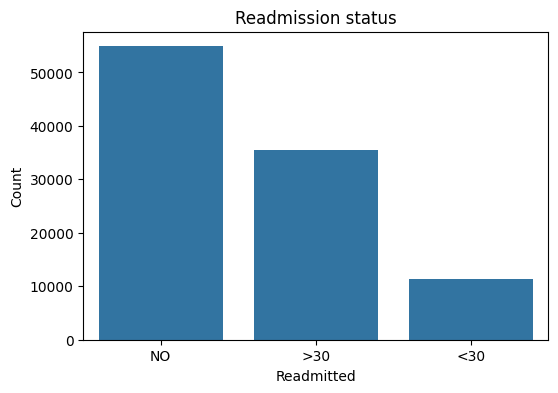

In [100]:
plt.figure(figsize=(6, 4))
sns.countplot(x="readmitted", data=data, order=["NO", ">30", "<30"])
plt.xlabel("Readmitted")
plt.ylabel("Count")
plt.title("Readmission status")
plt.show()

In [101]:
data['readmitted'].value_counts(normalize=True) * 100

readmitted
NO     53.911916
>30    34.928169
<30    11.159916
Name: proportion, dtype: float64

## 4. Numerical EDA

Numerical EDA focused on clinically meaningful counts and utilization measures (length of stay, procedures, medications, diagnoses, and prior inpatient/emergency/outpatient visits). Identifier fields and coded admission/discharge IDs were excluded from continuous comparisons because they are not quantitative clinical measurements.


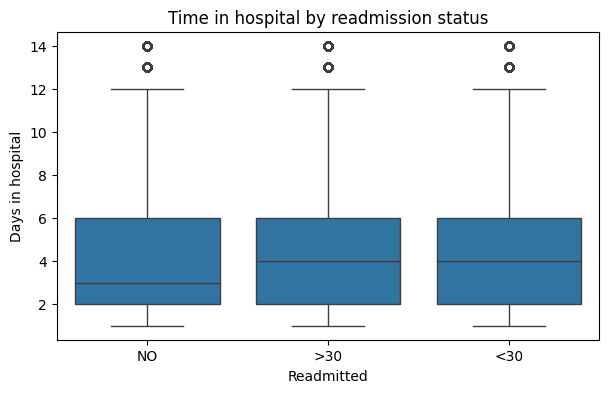

In [102]:
plt.figure(figsize=(7, 4))
sns.boxplot(data=data, x="readmitted", y="time_in_hospital", order=["NO", ">30", "<30"])
plt.xlabel("Readmitted")
plt.ylabel("Days in hospital")
plt.title("Time in hospital by readmission status")
plt.show()


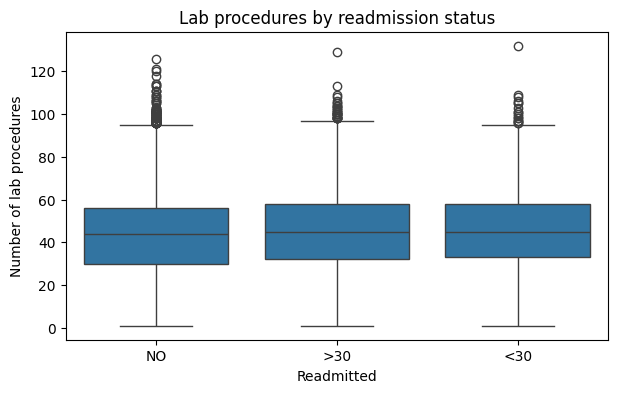

In [103]:
plt.figure(figsize=(7, 4))
sns.boxplot(data=data, x="readmitted", y="num_lab_procedures", order=["NO", ">30", "<30"])
plt.xlabel("Readmitted")
plt.ylabel("Number of lab procedures")
plt.title("Lab procedures by readmission status")
plt.show()


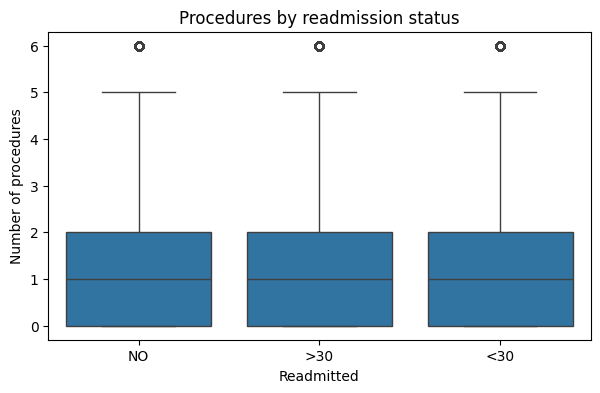

In [104]:
plt.figure(figsize=(7, 4))
sns.boxplot(data=data, x="readmitted", y="num_procedures", order=["NO", ">30", "<30"])
plt.xlabel("Readmitted")
plt.ylabel("Number of procedures")
plt.title("Procedures by readmission status")
plt.show()


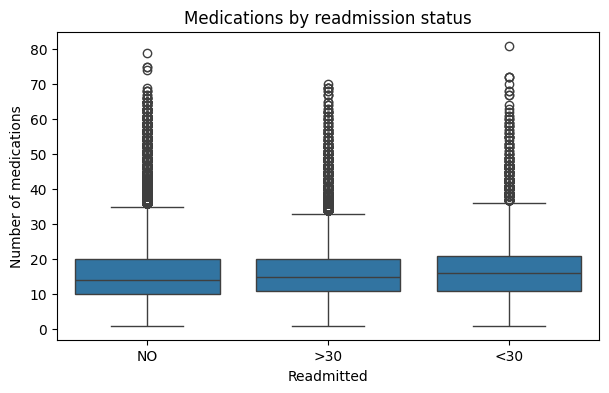

In [105]:
plt.figure(figsize=(7, 4))
sns.boxplot(data=data, x="readmitted", y="num_medications", order=["NO", ">30", "<30"])
plt.xlabel("Readmitted")
plt.ylabel("Number of medications")
plt.title("Medications by readmission status")
plt.show()


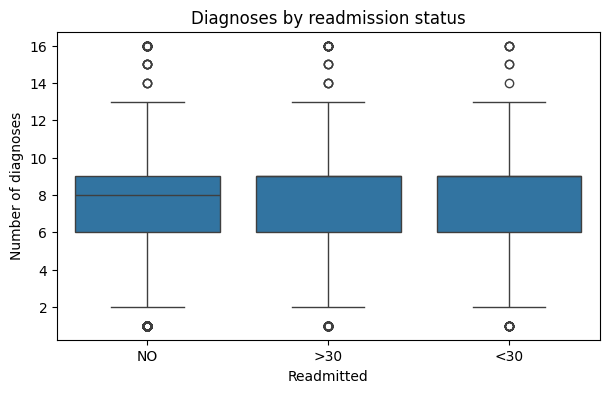

In [106]:
plt.figure(figsize=(7, 4))
sns.boxplot(data=data, x="readmitted", y="number_diagnoses", order=["NO", ">30", "<30"])
plt.xlabel("Readmitted")
plt.ylabel("Number of diagnoses")
plt.title("Diagnoses by readmission status")
plt.show()


In [107]:
data.groupby("readmitted")["number_diagnoses"].median().reindex(["NO", ">30", "<30"])

readmitted
NO     8.0
>30    9.0
<30    9.0
Name: number_diagnoses, dtype: float64

Because many encounters are capped near 9 diagnoses, the boxplot medians are hard to see visually. Medians were therefore calculated directly (above).


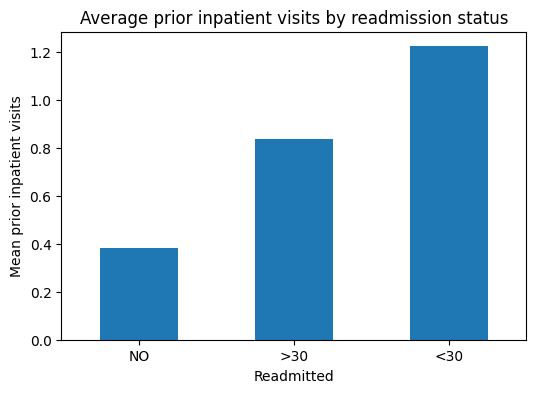

In [108]:
data.groupby("readmitted")["number_inpatient"].mean().reindex(["NO", ">30", "<30"]).plot(kind="bar", figsize=(6, 4))
plt.ylabel("Mean prior inpatient visits")
plt.xlabel("Readmitted")
plt.title("Average prior inpatient visits by readmission status")
plt.xticks(rotation=0)
plt.show()


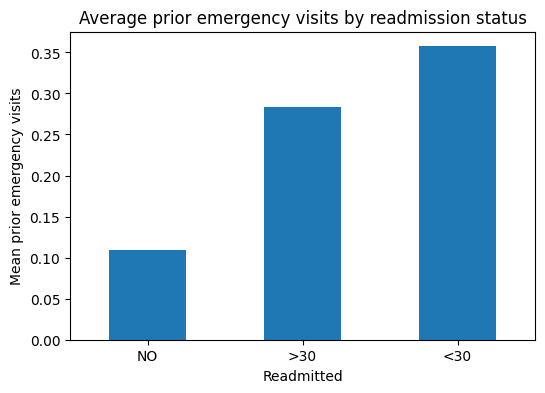

In [109]:
data.groupby("readmitted")["number_emergency"].mean().reindex(["NO", ">30", "<30"]).plot(kind="bar", figsize=(6, 4))
plt.ylabel("Mean prior emergency visits")
plt.xlabel("Readmitted")
plt.title("Average prior emergency visits by readmission status")
plt.xticks(rotation=0)
plt.show()


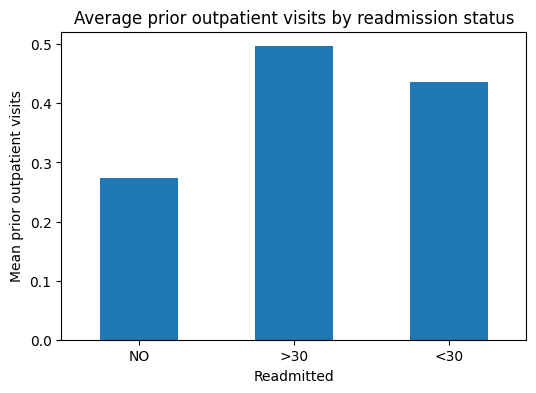

In [110]:
data.groupby("readmitted")["number_outpatient"].mean().reindex(["NO", ">30", "<30"]).plot(kind="bar", figsize=(6, 4))
plt.ylabel("Mean prior outpatient visits")
plt.xlabel("Readmitted")
plt.title("Average prior outpatient visits by readmission status")
plt.xticks(rotation=0)
plt.show()


Overall, several utilization and clinical-count features appear associated with readmission status. **Time in hospital**, **number of medications**, and **number of diagnoses** tended to be higher among readmitted encounters. Prior healthcare utilization — especially **previous inpatient** and **emergency** visits — showed the clearest separation, with the highest averages in the `<30` group. **Outpatient** visits were also elevated among readmitted encounters, though highest in the `>30` group. In contrast, **number of lab procedures** and **number of procedures** showed little difference in median values across readmission categories, suggesting weaker univariate relationships with readmission.


## 5. Categorical EDA

Categorical EDA focused on demographics (**race**, **gender**, **age**), care-process factors (**discharge disposition**, grouped for interpretability), diabetes treatment indicators (**diabetesMed**, **change**, **insulin**), and **medical specialty** (top specialties only, due to high cardinality). Individual diabetes medication flags were not plotted separately because `diabetesMed` already summarizes whether diabetes medications were prescribed. Raw ICD diagnosis codes (`diag_1/2/3`) were not plotted in detail here because of high cardinality.


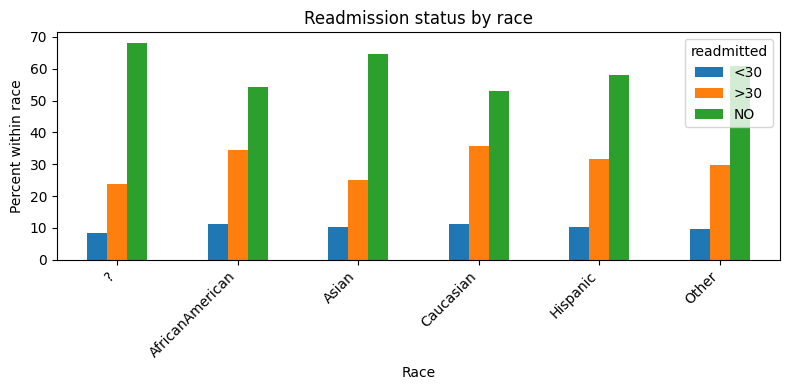

In [111]:
race_rate = pd.crosstab(data["race"], data["readmitted"], normalize="index") * 100
ax = race_rate.plot(kind="bar", figsize=(8, 4))
ax.set_xlabel("Race")
ax.set_ylabel("Percent within race")
ax.set_title("Readmission status by race")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


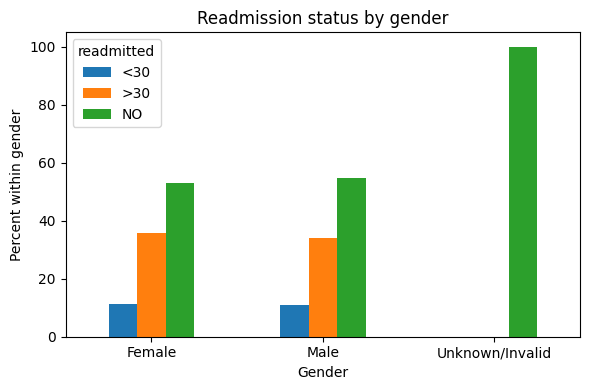

In [112]:
gender_rate = pd.crosstab(data["gender"], data["readmitted"], normalize="index") * 100
ax = gender_rate.plot(kind="bar", figsize=(6, 4))
ax.set_xlabel("Gender")
ax.set_ylabel("Percent within gender")
ax.set_title("Readmission status by gender")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


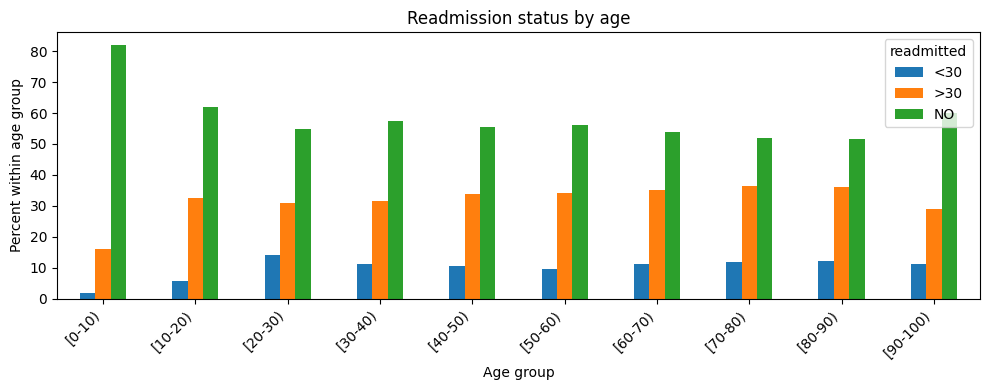

In [113]:
age_rate = pd.crosstab(data["age"], data["readmitted"], normalize="index") * 100
ax = age_rate.plot(kind="bar", figsize=(10, 4))
ax.set_xlabel("Age group")
ax.set_ylabel("Percent within age group")
ax.set_title("Readmission status by age")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


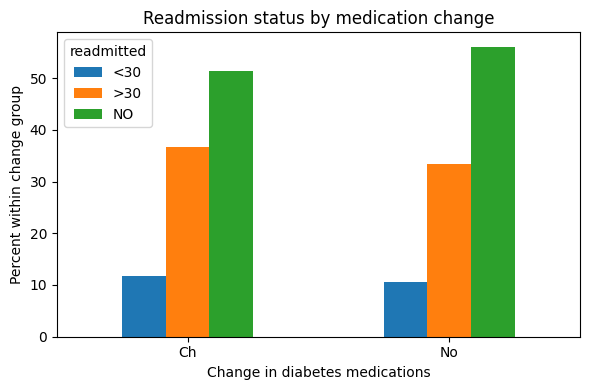

In [114]:
change_rate = pd.crosstab(data["change"], data["readmitted"], normalize="index") * 100
ax = change_rate.plot(kind="bar", figsize=(6, 4))
ax.set_xlabel("Change in diabetes medications")
ax.set_ylabel("Percent within change group")
ax.set_title("Readmission status by medication change")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


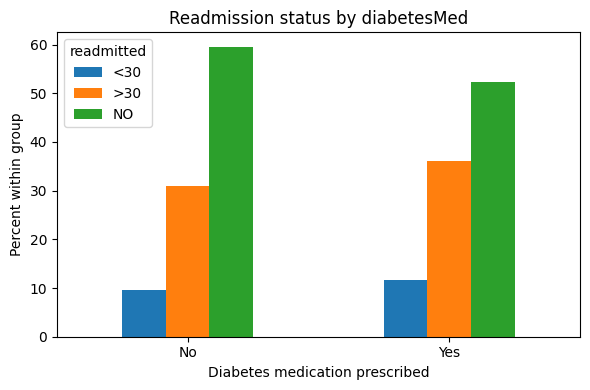

In [115]:
diabetes_rate = pd.crosstab(data["diabetesMed"], data["readmitted"], normalize="index") * 100
ax = diabetes_rate.plot(kind="bar", figsize=(6, 4))
ax.set_xlabel("Diabetes medication prescribed")
ax.set_ylabel("Percent within group")
ax.set_title("Readmission status by diabetesMed")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


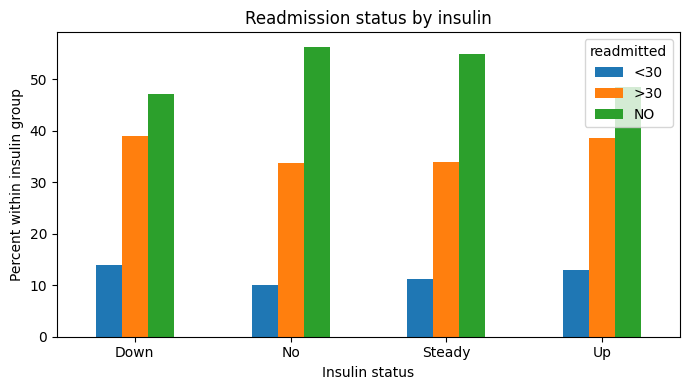

In [116]:
insulin_rate = pd.crosstab(data["insulin"], data["readmitted"], normalize="index") * 100
ax = insulin_rate.plot(kind="bar", figsize=(7, 4))
ax.set_xlabel("Insulin status")
ax.set_ylabel("Percent within insulin group")
ax.set_title("Readmission status by insulin")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


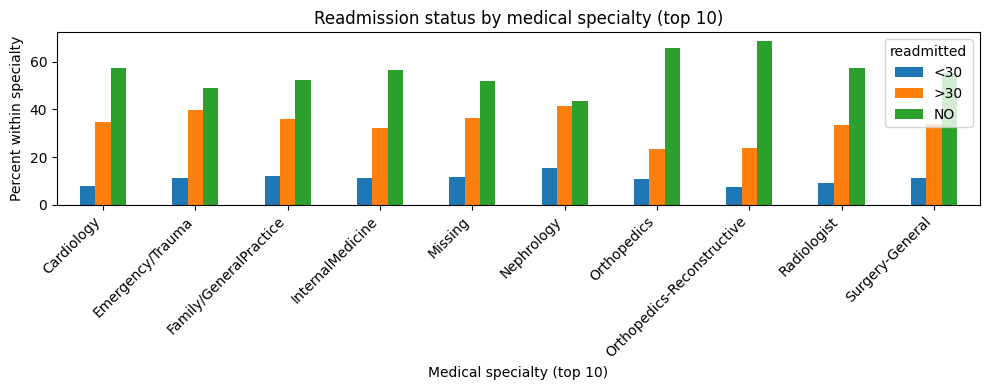

In [117]:
# High cardinality: plot top 10 specialties only (treat "?" as Missing)
specialty = data["medical_specialty"].replace("?", "Missing")
top_specialties = specialty.value_counts().head(10).index
specialty_plot = data.loc[specialty.isin(top_specialties)].copy()
specialty_plot["medical_specialty"] = specialty.loc[specialty.isin(top_specialties)].values

specialty_rate = pd.crosstab(
    specialty_plot["medical_specialty"],
    specialty_plot["readmitted"],
    normalize="index",
) * 100

ax = specialty_rate.plot(kind="bar", figsize=(10, 4))
ax.set_xlabel("Medical specialty (top 10)")
ax.set_ylabel("Percent within specialty")
ax.set_title("Readmission status by medical specialty (top 10)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


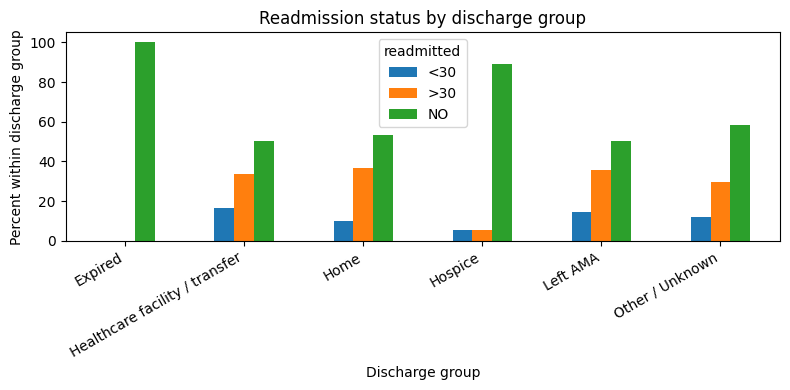

In [118]:
discharge_labels = {
    1: "Home",
    2: "Short term hospital",
    3: "SNF",
    4: "ICF",
    5: "Other inpatient care",
    6: "Home with home health",
    7: "Left AMA",
    8: "Home under Home IV",
    9: "Admitted as inpatient",
    10: "Neonate aftercare",
    11: "Expired",
    12: "Still patient / outpatient return",
    13: "Hospice / home",
    14: "Hospice / medical facility",
    15: "Swing bed",
    16: "Another institution outpatient",
    17: "This institution outpatient",
    18: "NULL",
    19: "Expired at home",
    20: "Expired in medical facility",
    21: "Expired, place unknown",
    22: "Rehab facility",
    23: "Long term care hospital",
    24: "Nursing facility (Medicaid)",
    25: "Not Mapped",
    26: "Unknown/Invalid",
    27: "Federal health care facility",
    28: "Psychiatric hospital",
    29: "Critical Access Hospital",
    30: "Other health care institution",
}

data["discharge_disposition"] = data["discharge_disposition_id"].map(discharge_labels)

def map_discharge_group(x):
    if x in [1, 6, 8]:
        return "Home"
    if x in [2, 3, 4, 5, 10, 15, 16, 17, 22, 23, 24, 27, 28, 29, 30]:
        return "Healthcare facility / transfer"
    if x in [13, 14]:
        return "Hospice"
    if x in [11, 19, 20, 21]:
        return "Expired"
    if x == 7:
        return "Left AMA"
    return "Other / Unknown"

data["discharge_group"] = data["discharge_disposition_id"].map(map_discharge_group)

discharge_group_rate = pd.crosstab(
    data["discharge_group"], data["readmitted"], normalize="index"
) * 100
ax = discharge_group_rate.plot(kind="bar", figsize=(8, 4))
ax.set_xlabel("Discharge group")
ax.set_ylabel("Percent within discharge group")
ax.set_title("Readmission status by discharge group")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()


Several categorical features appear associated with readmission status. **Race** showed differences in readmission patterns, with higher readmission rates among African American and Caucasian encounters relative to other groups. **Age** also varied by readmission status, suggesting age group is a relevant demographic factor.

Diabetes treatment indicators mattered as well: encounters with **diabetes medication** had higher readmission rates, while a **change in medication** was more strongly associated with `>30` readmissions. **Insulin** status also showed variation across readmission groups. **Discharge group** showed a clear pattern — Hospice had the lowest readmission rate (expected for end-of-life care), while Home and Left AMA had higher readmission rates. Among common **medical specialties**, readmission rates varied, supporting specialty as a potentially useful feature after grouping rare levels.

In contrast, **gender** showed little difference in readmission rates across groups.

Hospice and expired encounters may be excluded before modeling, since low readmission there reflects care pathway/outcome rather than successful recovery.


### EDA summary — features to prioritize in modeling

Based on the numerical and categorical EDA, the following features appear most promising for predicting early readmission:

- **Prior utilization:** `number_inpatient`, `number_emergency`, and (to a lesser extent) `number_outpatient`
- **Clinical intensity / complexity:** `time_in_hospital`, `num_medications`, `number_diagnoses`
- **Care process / discharge:** grouped `discharge_group` (consider excluding Expired/Hospice before modeling)
- **Demographics:** `age`, `race` (weaker: `gender`)
- **Diabetes treatment:** `diabetesMed`, `change`, `insulin`
- **Provider context:** `medical_specialty` (with rare specialties collapsed)

Weaker variables included `num_lab_procedures` and `num_procedures`. High-cardinality diagnosis codes (`diag_1/2/3`) were not deeply explored in EDA plots and can be optionally engineered later.



## 6. Preprocessing


In [119]:
# 1) Treat "?" as missing
data = data.replace("?", np.nan)

# 2) Drop near-empty column
data = data.drop(columns=["weight"])

# 3) Refresh column types
cat_cols = data.select_dtypes(include=["object"]).columns
num_cols = data.select_dtypes(include=["number"]).columns

# 4) Labs: "?" usually means not ordered — keep as explicit category
for col in ["max_glu_serum", "A1Cresult"]:
    if col in data.columns:
        data[col] = data[col].fillna("Not measured")

# 5) Other categoricals: keep missing as a category
other_cats = [c for c in cat_cols if c not in ["max_glu_serum", "A1Cresult"]]
data[other_cats] = data[other_cats].fillna("Missing")

# 6) Confirm
remaining = data.isna().sum()
print(remaining[remaining > 0])   # should be empty
print("Total missing:", data.isna().sum().sum())

Series([], dtype: int64)
Total missing: 0


Weight was dropped because nearly all values were missing (?), so it provided little usable signal. For max_glu_serum and A1Cresult, missingness typically indicates the lab was not ordered during the encounter rather than a lost measurement; these were therefore retained as categorical features with a "Not measured" level. Remaining categorical ? values were replaced with "Missing" to preserve absence-of-information as an explicit category.

In [120]:
data=data.drop(columns=["encounter_id","discharge_disposition_id"])
data = data[~data["discharge_group"].isin(["Expired", "Hospice"])]

In [121]:
data["readmitted_30d"] = (data["readmitted"] == "<30").astype(int)
data=data.drop(columns=["readmitted"])

## 7. Feature selection and train/test split

Raw ICD diagnosis codes (`diag_1`–`diag_3`) and the many individual diabetes medication flags are dropped because they are high-cardinality or redundant with simpler features already kept (`diabetesMed`, `change`, `insulin`, and grouped discharge).

Because rows are **encounters** and the same patient can appear more than once, the split is done at the **patient** level: unique `patient_nbr` values are split 80/20, then all of each patient's encounters go to train or test. That prevents the same patient from leaking across folds. `patient_nbr` is then dropped from the feature matrices. A quick print confirms the diagnosis columns are gone before modeling.


In [122]:
diag_cols = ["diag_1", "diag_2", "diag_3"]
med_cols = [
    "metformin", "repaglinide", "nateglinide", "chlorpropamide",
    "glimepiride", "acetohexamide", "glipizide", "glyburide",
    "tolbutamide", "pioglitazone", "rosiglitazone", "acarbose",
    "miglitol", "troglitazone", "tolazamide", "examide",
    "citoglipton", "glyburide-metformin", "glipizide-metformin",
    "glimepiride-pioglitazone", "metformin-rosiglitazone",
    "metformin-pioglitazone",
]

drop_cols = [c for c in diag_cols + med_cols + ["discharge_disposition"] if c in data.columns]
data = data.drop(columns=drop_cols)

# Patient-level split: no shared patient_nbr between train and test
patients = data["patient_nbr"].unique()
train_patients, test_patients = train_test_split(
    patients, test_size=0.2, random_state=42
)

train_df = data[data["patient_nbr"].isin(train_patients)]
test_df = data[data["patient_nbr"].isin(test_patients)]

X_train = train_df.drop(columns=["readmitted_30d", "patient_nbr"])
y_train = train_df["readmitted_30d"]
X_test = test_df.drop(columns=["readmitted_30d", "patient_nbr"])
y_test = test_df["readmitted_30d"]

print([c for c in ["diag_1", "diag_2", "diag_3"] if c in X_train.columns])  # should be []
print("Train/test rows:", len(X_train), len(X_test))
print("Patient overlap:", len(set(train_patients) & set(test_patients)))  # should be 0


[]


## 8. Logistic Regression


In [123]:
from sklearn.preprocessing import StandardScaler
num_cols_train = X_train.select_dtypes(include=["number"]).columns.tolist()
cat_cols_train = X_train.select_dtypes(include=["object"]).columns.tolist()
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols_train),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols_train),
    ]
)
model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(
        max_iter=2000,
        class_weight="balanced",
    )),
])

In [124]:
# Fit the Pipeline (encodes categoricals, then logistic regression)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred, digits=3))
cm = confusion_matrix(y_test, y_pred)
print(cm)


Accuracy: 0.6550884516000796
              precision    recall  f1-score   support

           0      0.918     0.669     0.774     17783
           1      0.179     0.549     0.270      2341

    accuracy                          0.655     20124
   macro avg      0.549     0.609     0.522     20124
weighted avg      0.832     0.655     0.716     20124

[[11898  5885]
 [ 1056  1285]]


In [125]:
y_prob = model.predict_proba(X_test)[:, 1]
y_pred = model.predict(X_test)
print("ROC-AUC:", roc_auc_score(y_test, y_prob))
print("PR-AUC :", average_precision_score(y_test, y_prob))  # better with imbalance
print("Recall (class 1):", recall_score(y_test, y_pred))
print("Precision (class 1):", precision_score(y_test, y_pred))
print("F1 (class 1):", f1_score(y_test, y_pred))





ROC-AUC: 0.6508753314286333
PR-AUC : 0.2164818208378532
Recall (class 1): 0.548910721913712
Precision (class 1): 0.1792189679218968
F1 (class 1): 0.270213437072863


In [126]:
from sklearn.model_selection import cross_val_score

cv_auc = cross_val_score(
    model, X_train, y_train,
    cv=5,
    scoring="roc_auc"
)
print("CV ROC-AUC:", cv_auc.mean(), "+/-", cv_auc.std())

CV ROC-AUC: 0.6541156218807084 +/- 0.01073086605506068


In [127]:

cv_ap = cross_val_score(
    model,
    X_train,
    y_train,
    cv=5,
    scoring="average_precision",   # this is PR-AUC
)
print("CV PR-AUC:", cv_ap.mean(), "+/-", cv_ap.std())

CV PR-AUC: 0.20127022390609944 +/- 0.006802986950098961


After rare-category collapse (the final logistic metrics used below), balanced logistic regression reached an accuracy of about **0.657**. Because 30-day readmission is uncommon, accuracy alone is not enough. For the positive class (`<30`), precision was low (~0.179), meaning that only about 18% of encounters predicted as early readmissions were actually readmitted within 30 days. Recall was higher (~0.544), meaning the model identified about 54% of true early readmissions. The F1-score (~0.270) reflects this precision–recall tradeoff. Test ROC-AUC was ~0.649 and PR-AUC ~0.214, indicating limited ability to rank early-readmission cases highly. Overall, balancing improved detection of the positive class relative to an accuracy-only approach, but positive-class performance remains limited and motivates stronger models.


CV ROC-AUC (~0.65) and PR-AUC (~0.20) aligned with test-set metrics, indicating stable but modest performance under the patient-level split, especially for the rare positive class.


In [128]:

# Feature names after preprocessing
feature_names = model.named_steps["preprocessor"].get_feature_names_out()
coefs = model.named_steps["classifier"].coef_[0]

coef_df = pd.DataFrame({
    "feature": feature_names,
    "coefficient": coefs,
    "odds_ratio": np.exp(coefs),
}).sort_values("coefficient", ascending=False)

print("Top features increasing 30-day readmission risk:")
display(coef_df.head(15))

print("\nTop features decreasing 30-day readmission risk:")
display(coef_df.tail(15))

Top features increasing 30-day readmission risk:


,feature,coefficient,odds_ratio
61,cat__medical_specialty_Hematology,1.469728,4.348052
64,cat__medical_specialty_InfectiousDiseases,1.015090,2.759612
47,cat__medical_specialty_AllergyandImmunology,0.961426,2.615422
62,cat__medical_specialty_Hematology/Oncology,0.958007,2.606496
73,cat__medical_specialty_Oncology,0.798716,2.222684
43,cat__payer_code_SI,0.575334,1.777723
67,cat__medical_specialty_Nephrology,0.413878,1.512673
97,cat__medical_specialty_Psychiatry-Child/Adoles...,0.412088,1.509967
102,cat__medical_specialty_Resident,0.404122,1.497986
49,cat__medical_specialty_Anesthesiology-Pediatric,0.385890,1.470923



Top features decreasing 30-day readmission risk:


,feature,coefficient,odds_ratio
76,cat__medical_specialty_Orthopedics-Reconstructive,-0.268146,0.764796
137,cat__discharge_group_Home,-0.294554,0.744864
20,cat__age_[10-20),-0.320234,0.725979
72,cat__medical_specialty_ObstetricsandGynecology,-0.364596,0.694477
108,cat__medical_specialty_Surgery-Cardiovascular/...,-0.368378,0.691856
68,cat__medical_specialty_Neurology,-0.379333,0.684318
88,cat__medical_specialty_Pediatrics-Neurology,-0.402602,0.668578
77,cat__medical_specialty_Osteopath,-0.404305,0.667440
19,cat__age_[0-10),-0.472745,0.623289
56,cat__medical_specialty_Endocrinology,-0.579487,0.560186


After fitting the initial logistic model, coefficient inspection showed that rare levels might be dominating the top-ranked features. Because uncommon categories can produce unstable odds ratios, categorical columns appearing in fewer than 1% of training encounters were collapsed into an "Other" category (using training frequencies only, then applied to the test set). The model was then refit, and feature importance/coefficients were re-examined.

In [129]:
def collapse_rare_train_test(train_col, test_col, min_frac=0.01, other_label="Other"):
    """Collapse rare levels using train frequencies only; apply same keep-set to test."""
    rates = train_col.value_counts(normalize=True)
    keep = rates[rates >= min_frac].index
    return (
        train_col.where(train_col.isin(keep), other_label),
        test_col.where(test_col.isin(keep), other_label),
    )

for col in cat_cols_train:
    X_train[col], X_test[col] = collapse_rare_train_test(X_train[col], X_test[col])

model.fit(X_train, y_train)

# Re-score after rare-level collapse (these are the final logistic metrics)
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]
print("Accuracy:", accuracy_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))
print("PR-AUC :", average_precision_score(y_test, y_prob))
print("Recall (class 1):", recall_score(y_test, y_pred))
print("Precision (class 1):", precision_score(y_test, y_pred))
print("F1 (class 1):", f1_score(y_test, y_pred))
print(classification_report(y_test, y_pred, digits=3))

feature_names = model.named_steps["preprocessor"].get_feature_names_out()
coefs = model.named_steps["classifier"].coef_[0]

coef_df = pd.DataFrame({
    "feature": feature_names,
    "coefficient": coefs,
    "odds_ratio": np.exp(coefs),
}).sort_values("coefficient", ascending=False)

print("Top risk-increasing features:")
display(coef_df.head(15))

print("\nTop protective features:")
display(coef_df.tail(15))




Accuracy: 0.6569270522758894
ROC-AUC: 0.648747322934375
PR-AUC : 0.21446881136622487
Recall (class 1): 0.5442118752669799
Precision (class 1): 0.17915904936014626
F1 (class 1): 0.2695725772323318
              precision    recall  f1-score   support

           0      0.918     0.672     0.776     17783
           1      0.179     0.544     0.270      2341

    accuracy                          0.657     20124
   macro avg      0.549     0.608     0.523     20124
weighted avg      0.832     0.657     0.717     20124

Top risk-increasing features:


,feature,coefficient,odds_ratio
8,num__number_inpatient,0.363900,1.438931
65,cat__discharge_group_Healthcare facility / tra...,0.282960,1.327051
43,cat__medical_specialty_Nephrology,0.257507,1.293701
33,cat__payer_code_Missing,0.191217,1.210723
34,cat__payer_code_OG,0.186506,1.205031
19,cat__age_[20-30),0.148054,1.159576
57,cat__insulin_Down,0.137600,1.147517
24,cat__age_[70-80),0.115130,1.122020
25,cat__age_[80-90),0.111095,1.117501
40,cat__medical_specialty_Family/GeneralPractice,0.104978,1.110686



Top protective features:


,feature,coefficient,odds_ratio
22,cat__age_[50-60),-0.061417,0.940431
61,cat__change_Ch,-0.069071,0.933260
63,cat__diabetesMed_No,-0.090740,0.913255
27,cat__payer_code_BC,-0.095839,0.908610
59,cat__insulin_Steady,-0.096939,0.907612
52,cat__max_glu_serum_Not measured,-0.106980,0.898544
68,cat__discharge_group_Other / Unknown,-0.126507,0.881168
58,cat__insulin_No,-0.129560,0.878482
13,cat__race_Missing,-0.135493,0.873286
28,cat__payer_code_CM,-0.161385,0.850964


After collapsing rare categorical levels and refitting, the logistic coefficients were more stable and aligned with EDA. The strongest risk-increasing factor was prior inpatient utilization (number_inpatient, OR ≈ 1.44). Higher odds of 30-day readmission were also associated with discharge to a healthcare facility/transfer, older age groups (especially 60–90), insulin downregulation, and specialties such as nephrology and family/general practice.

Protective factors included discharge home (OR ≈ 0.76), no diabetes medication / no insulin, stable insulin, and specialties such as cardiology and orthopedics-reconstructive. Overall, prior utilization and discharge disposition were the most actionable signals for early readmission risk.

## 9. Random Forest


Because 30-day readmission is uncommon, the Random Forest used `class_weight="balanced"`. Hyperparameters were tuned with `RandomizedSearchCV` over a small grid (about 2–3 values per parameter: `n_estimators`, `max_depth`, `min_samples_leaf`, and `max_features`). Ten random combinations were evaluated with 3-fold CV on the training data, scoring by average precision (PR-AUC). The best model was then used to predict the held-out test set.


In [130]:
from sklearn.model_selection import RandomizedSearchCV

num_cols_train = X_train.select_dtypes(include=["number"]).columns.tolist()
cat_cols_train = X_train.select_dtypes(include=["object"]).columns.tolist()

rf_preprocessor = ColumnTransformer(
    transformers=[
        ("num", "passthrough", num_cols_train),  # trees don't need scaling
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols_train),
    ]
)

rf_model = Pipeline([
    ("preprocessor", rf_preprocessor),
    ("classifier", RandomForestClassifier(
        class_weight="balanced",
        random_state=42,
        n_jobs=-1,
    )),
])

param_dist = {
    "classifier__n_estimators": [200, 300, 500],
    "classifier__max_depth": [None, 10, 20],
    "classifier__min_samples_leaf": [1, 2, 5],
    "classifier__max_features": ["sqrt", 0.5],
}

rf_search = RandomizedSearchCV(
    estimator=rf_model,
    param_distributions=param_dist,
    n_iter=10,
    scoring="average_precision",  # better for imbalance
    cv=3,
    random_state=42,
    n_jobs=-1,
    verbose=1,
)

rf_search.fit(X_train, y_train)
print("Best params:", rf_search.best_params_)
print("Best CV PR-AUC:", rf_search.best_score_)

# Final RF = best estimator from search
rf_model = rf_search.best_estimator_
y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_rf))
print("PR-AUC :", average_precision_score(y_test, y_prob_rf))
print("Recall (class 1):", recall_score(y_test, y_pred_rf))
print("Precision (class 1):", precision_score(y_test, y_pred_rf))
print("F1 (class 1):", f1_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf, digits=3))


Fitting 3 folds for each of 10 candidates, totalling 30 fits


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Best params: {'classifier__n_estimators': 500, 'classifier__min_samples_leaf': 5, 'classifier__max_features': 0.5, 'classifier__max_depth': None}
Best CV PR-AUC: 0.1974768807569066
Accuracy: 0.8713973365136156
ROC-AUC: 0.6476569314683931
PR-AUC : 0.20864160909183566
Recall (class 1): 0.09184109354976505
Precision (class 1): 0.3175775480059084
F1 (class 1): 0.1424784625579854
              precision    recall  f1-score   support

           0      0.891     0.974     0.930     17783
           1      0.318     0.092     0.142      2341

    accuracy                          0.871     20124
   macro avg      0.604     0.533     0.536     20124
weighted avg      0.824     0.871     0.839     20124



Test accuracy was about **87%**, but that mainly reflects the majority class. For this imbalanced problem, **PR-AUC (~0.21)** and **recall of the `<30` class** matter more. With the patient-level split, the tuned forest still ranks only modestly (ROC-AUC ~0.65) and recovers very few early readmissions (recall ~0.09), while precision on the positive class is higher (~0.32) because it flags positives more rarely.


In [131]:
feature_names = rf_model.named_steps["preprocessor"].get_feature_names_out()
importances = rf_model.named_steps["classifier"].feature_importances_
rf_imp = pd.DataFrame({
    "feature": feature_names,
    "importance": importances,
}).sort_values("importance", ascending=False)
display(rf_imp.head(20))

,feature,importance
3,num__num_lab_procedures,0.157485
5,num__num_medications,0.121993
2,num__time_in_hospital,0.078383
8,num__number_inpatient,0.073687
4,num__num_procedures,0.052438
9,num__number_diagnoses,0.045260
0,num__admission_type_id,0.029774
1,num__admission_source_id,0.026139
6,num__number_outpatient,0.021515
42,cat__medical_specialty_Missing,0.017683


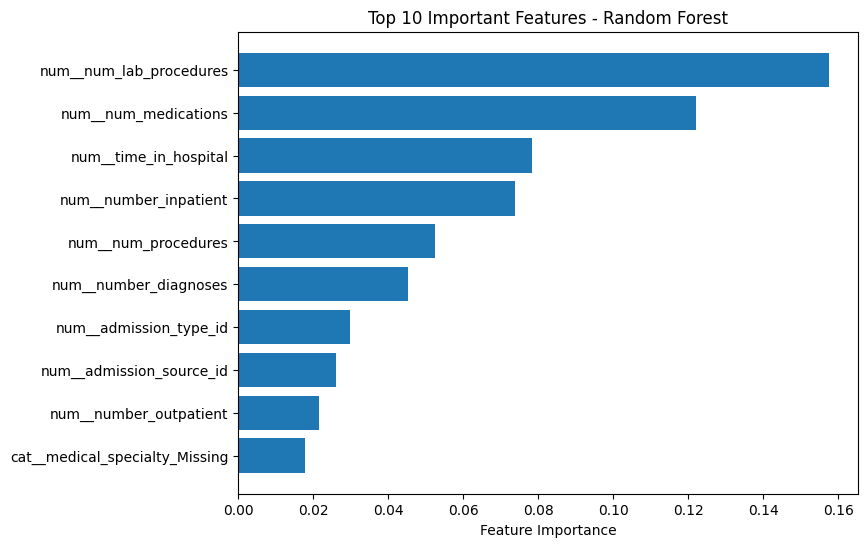

In [132]:
top10 = rf_imp.head(10)

plt.figure(figsize=(8,6))
plt.barh(top10["feature"], top10["importance"])
plt.xlabel("Feature Importance")
plt.title("Top 10 Important Features - Random Forest")
plt.gca().invert_yaxis()
plt.show()


Random Forest importance is led by **prior inpatient visits**, then encounter intensity measures (`num_lab_procedures`, `num_medications`, `time_in_hospital`, `number_diagnoses`). That matches the EDA story: utilization and clinical complexity drive early-readmission risk more than demographics alone.

## 10. XGBoost


Because 30-day readmission is uncommon, XGBoost used `scale_pos_weight` (negative/positive class ratio on the training set) to up-weight the minority class. Hyperparameters were tuned with `RandomizedSearchCV` over a small grid (about 2–3 values per parameter: `n_estimators`, `max_depth`, `learning_rate`, `subsample`, `colsample_bytree`, and `min_child_weight`). Fifteen random combinations were evaluated with 3-fold CV on the training data, scoring by average precision (PR-AUC). The best model was then used to predict the held-out test set.


In [133]:
from xgboost import XGBClassifier
from sklearn.model_selection import RandomizedSearchCV

# imbalance ratio: neg/pos
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
scale_pos_weight = neg / pos
print("scale_pos_weight:", scale_pos_weight)

num_cols_train = X_train.select_dtypes(include=["number"]).columns.tolist()
cat_cols_train = X_train.select_dtypes(include=["object"]).columns.tolist()

xgb_preprocessor = ColumnTransformer(
    transformers=[
        ("num", "passthrough", num_cols_train),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols_train),
    ]
)

# Must wrap preprocessor + classifier (like RF); RandomizedSearchCV params use classifier__*
xgb_model = Pipeline([
    ("preprocessor", xgb_preprocessor),
    ("classifier", XGBClassifier(
        objective="binary:logistic",
        eval_metric="aucpr",
        scale_pos_weight=scale_pos_weight,
        random_state=42,
        n_jobs=-1,
    )),
])

param_dist = {
    "classifier__n_estimators": [200, 300, 500],
    "classifier__max_depth": [3, 4, 5, 6],
    "classifier__learning_rate": [0.01, 0.05, 0.1],
    "classifier__subsample": [0.8, 1.0],
    "classifier__colsample_bytree": [0.8, 1.0],
    "classifier__min_child_weight": [1, 3, 5],
}
xgb_search = RandomizedSearchCV(
    estimator=xgb_model,
    param_distributions=param_dist,
    n_iter=15,
    scoring="average_precision",
    cv=3,
    random_state=42,
    n_jobs=-1,
    verbose=1,
)
xgb_search.fit(X_train, y_train)
print("Best params:", xgb_search.best_params_)
print("Best CV PR-AUC:", xgb_search.best_score_)
best_xgb = xgb_search.best_estimator_

scale_pos_weight: 7.828596901816561
Fitting 3 folds for each of 15 candidates, totalling 45 fits
Best params: {'classifier__subsample': 0.8, 'classifier__n_estimators': 200, 'classifier__min_child_weight': 5, 'classifier__max_depth': 4, 'classifier__learning_rate': 0.01, 'classifier__colsample_bytree': 0.8}
Best CV PR-AUC: 0.20505145284294893


In [134]:
best_xgb = xgb_search.best_estimator_

y_pred = best_xgb.predict(X_test)
y_prob = best_xgb.predict_proba(X_test)[:, 1]

print("ROC-AUC:", roc_auc_score(y_test, y_prob))
print("PR-AUC :", average_precision_score(y_test, y_prob))
print("Recall:", recall_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("F1:", f1_score(y_test, y_pred))
print(classification_report(y_test, y_pred, digits=3))

ROC-AUC: 0.6525998688974392
PR-AUC : 0.22052293125780154
Recall: 0.5997436992738147
Precision: 0.17482256257004108
F1: 0.27072888546085616
              precision    recall  f1-score   support

           0      0.923     0.627     0.747     17783
           1      0.175     0.600     0.271      2341

    accuracy                          0.624     20124
   macro avg      0.549     0.614     0.509     20124
weighted avg      0.836     0.624     0.691     20124



On the test set (patient-level split), tuned XGBoost reached ROC-AUC ~0.65 and PR-AUC ~0.22, slightly above logistic regression and Random Forest. With `scale_pos_weight`, it recovered far more early readmissions (recall ~0.60) than Random Forest (~0.09), at the cost of lower precision (~0.18) and lower overall accuracy (~0.62). That trade-off is expected for a rare positive class: the model flags more high-risk encounters, but many of those flags are false positives.


### Choosing a decision threshold

The model gives each encounter a **probability** of early readmission (for example 0.40 or 0.70). To get a yes/no answer, we pick a cutoff:

> If probability ≥ cutoff → predict “early readmission”

The default cutoff is **0.50**. That is just the usual default — not always the best choice when only about 11% of cases are early readmissions.

Below we try several cutoffs and keep the one with the best **F1** score (a balance between finding true cases and not flagging too many false ones). The model stays the same; only the cutoff changes.


,threshold,precision,recall,f1,accuracy
0,0.30,0.116339,0.999146,0.208411,0.117074
1,0.35,0.124204,0.949594,0.219675,0.215216
2,0.40,0.136041,0.852627,0.234644,0.352962
3,0.45,0.157323,0.692866,0.256422,0.532548
4,0.50,0.174823,0.599744,0.270729,0.624130
5,0.55,0.196068,0.455788,0.274187,0.719290
6,0.60,0.236851,0.290474,0.260936,0.808587
7,0.65,0.326165,0.116617,0.171806,0.869211
8,0.70,0.401496,0.068774,0.117433,0.879746


Best threshold by F1: 0.55
precision=0.196, recall=0.456, F1=0.274, accuracy=0.719


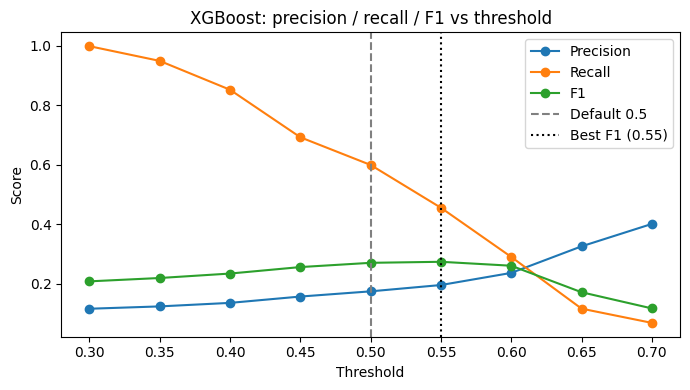


Operating threshold: 0.55
Accuracy: 0.7192903995229577
ROC-AUC: 0.6525998688974392
PR-AUC : 0.22052293125780154
Recall: 0.45578812473302005
Precision: 0.19606762219772142
F1: 0.27418733136322754
              precision    recall  f1-score   support

           0      0.913     0.754     0.826     17783
           1      0.196     0.456     0.274      2341

    accuracy                          0.719     20124
   macro avg      0.555     0.605     0.550     20124
weighted avg      0.830     0.719     0.762     20124



In [143]:
thresholds = np.round(np.arange(0.30, 0.71, 0.05), 2)

rows = []
for t in thresholds:
    yp = (y_prob >= t).astype(int)
    rows.append({
        "threshold": t,
        "precision": precision_score(y_test, yp, zero_division=0),
        "recall": recall_score(y_test, yp, zero_division=0),
        "f1": f1_score(y_test, yp, zero_division=0),
        "accuracy": accuracy_score(y_test, yp),
    })

thr_df = pd.DataFrame(rows)
display(thr_df)

best_row = thr_df.loc[thr_df["f1"].idxmax()]
best_threshold = float(best_row["threshold"])
print(f"Best threshold by F1: {best_threshold:.2f}")
print(
    f"precision={best_row['precision']:.3f}, "
    f"recall={best_row['recall']:.3f}, "
    f"F1={best_row['f1']:.3f}, "
    f"accuracy={best_row['accuracy']:.3f}"
)

plt.figure(figsize=(7, 4))
plt.plot(thr_df["threshold"], thr_df["precision"], marker="o", label="Precision")
plt.plot(thr_df["threshold"], thr_df["recall"], marker="o", label="Recall")
plt.plot(thr_df["threshold"], thr_df["f1"], marker="o", label="F1")
plt.axvline(0.5, color="gray", ls="--", label="Default 0.5")
plt.axvline(best_threshold, color="black", ls=":", label=f"Best F1 ({best_threshold:.2f})")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("XGBoost: precision / recall / F1 vs threshold")
plt.legend()
plt.tight_layout()
plt.show()

# Final operating point
FINAL_THRESHOLD = best_threshold  # ~0.55 on this split
y_pred_tuned = (y_prob >= FINAL_THRESHOLD).astype(int)

print(f"\nOperating threshold: {FINAL_THRESHOLD:.2f}")
print("Accuracy:", accuracy_score(y_test, y_pred_tuned))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))
print("PR-AUC :", average_precision_score(y_test, y_prob))
print("Recall:", recall_score(y_test, y_pred_tuned))
print("Precision:", precision_score(y_test, y_pred_tuned))
print("F1:", f1_score(y_test, y_pred_tuned))
print(classification_report(y_test, y_pred_tuned, digits=3))


**Chosen cutoff: 0.55**

Among the cutoffs we tried, **0.55** had the highest F1, so we use that as our final yes/no rule.

- **0.55** → best overall balance (our choice)
- **0.50** → flags more people (catches more true cases, but more false alarms)
- **0.45** → flags even more people (useful only if we want aggressive screening)


In [144]:
feature_names = best_xgb.named_steps["preprocessor"].get_feature_names_out()
importances = best_xgb.named_steps["classifier"].feature_importances_
xgb_imp = pd.DataFrame({
    "feature": feature_names,
    "importance": importances,
}).sort_values("importance", ascending=False)
display(xgb_imp.head(20))

,feature,importance
65,cat__discharge_group_Healthcare facility / tra...,0.130122
8,num__number_inpatient,0.119703
66,cat__discharge_group_Home,0.069945
7,num__number_emergency,0.037839
9,num__number_diagnoses,0.036718
33,cat__payer_code_Missing,0.020323
58,cat__insulin_No,0.020250
2,num__time_in_hospital,0.019749
22,cat__age_[50-60),0.018722
27,cat__payer_code_BC,0.018326


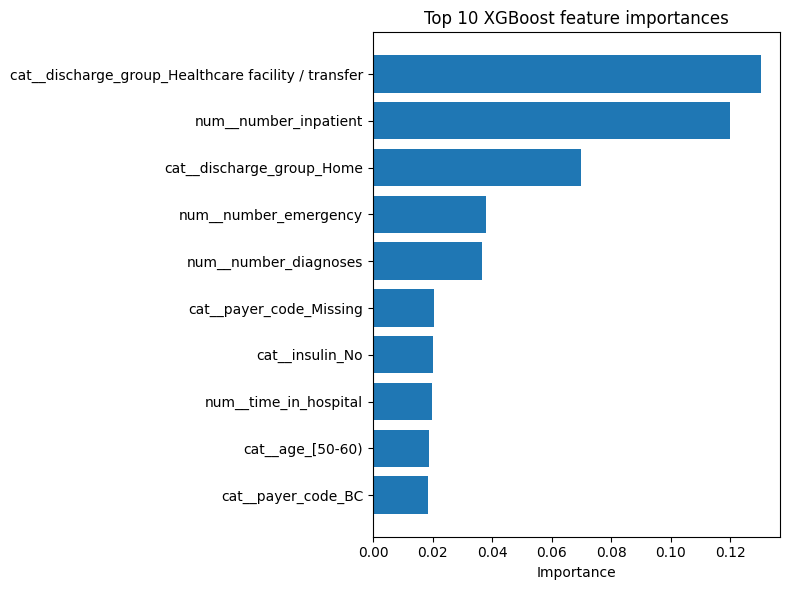

In [145]:
top10_xgb = xgb_imp.head(10).sort_values("importance")  # smallest at top for barh
plt.figure(figsize=(8, 6))
plt.barh(top10_xgb["feature"], top10_xgb["importance"])
plt.xlabel("Importance")
plt.title("Top 10 XGBoost feature importances")
plt.tight_layout()
plt.show()

XGBoost also ranks **prior inpatient visits** highest, but puts **discharge disposition** (healthcare facility/transfer vs home) next — a stronger care-process signal than in the Random Forest ranking. Emergency visits, number of diagnoses, and diabetes-medication status round out the top set. Exact ranks differ by model, but both point to the same drivers: prior utilization, discharge pathway, and clinical complexity.

## 11. Conclusion

| Model | Accuracy | ROC-AUC | PR-AUC | Recall (&lt;30) | Precision (&lt;30) | F1 (&lt;30) |
|-------|----------|---------|--------|-----------------|--------------------|-------------|
| Logistic Regression (balanced) | 0.657 | 0.649 | 0.214 | 0.544 | 0.179 | 0.270 |
| Random Forest (tuned, balanced) | 0.871 | 0.648 | 0.209 | 0.092 | 0.318 | 0.142 |
| XGBoost (tuned, default thresh 0.50) | 0.624 | **0.653** | **0.221** | 0.600 | 0.175 | 0.271 |
| **XGBoost (tuned, thresh 0.55)** | 0.719 | **0.653** | **0.221** | 0.456 | 0.196 | **0.274** |

Metrics are from a **patient-level** 80/20 split (`random_state=42`), so no patient appears in both train and test. ROC-AUC / PR-AUC do not change with the decision threshold.

**Takeaways**
- Accuracy is misleading: Random Forest looks best (~87%) mainly by predicting the majority class, while capturing very few true early readmissions (recall ~0.09).
- For ranking risk, XGBoost edges out the others on ROC-AUC and PR-AUC.
- Tuning the decision threshold to **0.55** (max F1) is the chosen operating point for the precision–recall tradeoff.
- Logistic Regression remains a strong, interpretable baseline on ranking metrics.
- Precision on `<30` stays low (~0.18–0.20) — useful for **screening**, not automatic intervention.
- Remaining limitations: richer ICD diagnosis grouping, probability calibration, and cost-sensitive thresholds before any clinical use.
